In [1]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16

# Camadas do Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, BatchNormalization

# Pré-processamento de imagens
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

# Otimizadores e callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.regularizers import l2


# Plotagem
import matplotlib.pyplot as plt

import os
import zipfile
import shutil
import random
import pandas as pd
from glob import glob
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Manipulação de arquivos
import os
import shutil
import random
import zipfile

percebendo que o modelo tem problema para a generalizar logo posso criar mascaras de seguimentação para facilitar o modelo onde ele deve treinar e remover o ruido logo esse segue a normalização

podemos usar o coco

In [ ]:
!pip install ultralytics


In [2]:
!unrar x /content/brain_tumor_dataset.rar ./brain_tumor_dataset/


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/brain_tumor_dataset.rar

Creating    ./brain_tumor_dataset                                     OK
Creating    ./brain_tumor_dataset/brain_tumor_dataset                 OK
Creating    ./brain_tumor_dataset/brain_tumor_dataset/no              OK
Extracting  ./brain_tumor_dataset/brain_tumor_dataset/no/1 no.jpeg         0%  OK 
Extracting  ./brain_tumor_dataset/brain_tumor_dataset/no/10 no.jpg         0%  OK 
Extracting  ./brain_tumor_dataset/brain_tumor_dataset/no/11 no.jpg         0%  OK 
Extracting  ./brain_tumor_dataset/brain_tumor_dataset/no/12 no.jpg         0%  OK 
Extracting  ./brain_tumor_dataset/brain_tumor_dataset/no/13 no.jpg         0%  OK 
Extracting  ./brain_tumor_dataset/brain_tumor_dataset/no/14 no.jpg         0%  OK 
Extracting  ./brain_tumor_dataset/brain_tumor_dataset/no/15 no.jpg         1%  OK 
Extracting 

In [5]:
#from ultralytics import YOLO
import cv2
import numpy as np
import os
import glob
import shutil
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# visão computacional

mudar a classficação da label

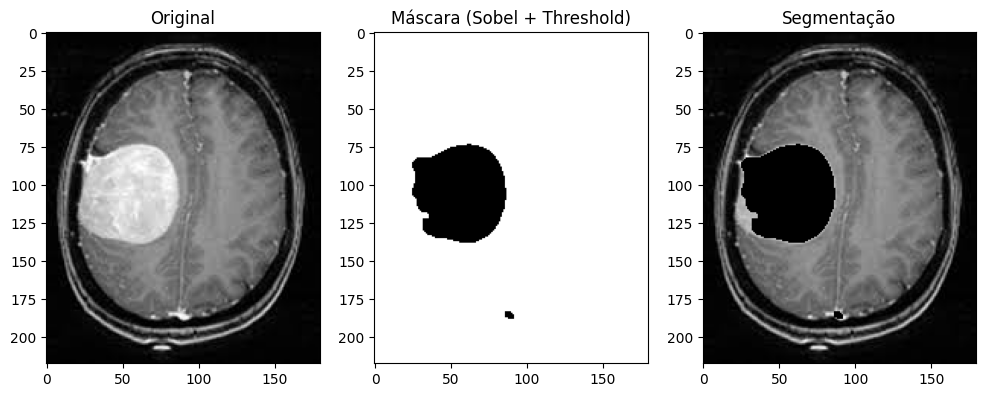

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Ler a imagem e converter para tons de cinza
img = cv2.imread('/content/brain_tumor_dataset/brain_tumor_dataset/yes/Y1.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Aplicar filtro para reduzir ruído
blur = cv2.medianBlur(img_gray, 5)



# 4. Thresholding para gerar máscara binária
_, mask = cv2.threshold(blur, 190, 255,  cv2.ADAPTIVE_THRESH_GAUSSIAN_C)  # ajuste o valor 50 se necessário

# 5. Refinar máscara com morfologia
kernel = np.ones((3,3), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

# 6. Encontrar contornos (opcional)
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
segmented = img.copy()
cv2.drawContours(segmented, contours, -1, (255, 255, 0), 2)

colored_mask = np.zeros_like(img)
colored_mask[mask > 0] = [255, 255, 0]  # Ciano em BGR

# Sobrepor com transparência na imagem original
result_colored = cv2.addWeighted(img, 0.7, colored_mask, 0.3, 0)

# 7. Aplicar a máscara à imagem original
result = cv2.bitwise_and(img, img, mask=mask)


# 8. Mostrar resultados
plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.subplot(1,3,2)
plt.title("Máscara (Sobel + Threshold)")
plt.imshow(mask, cmap='gray')

plt.subplot(1,3,3)
plt.title("Segmentação")
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.show()



Label salvo em: /content/Y1.txt


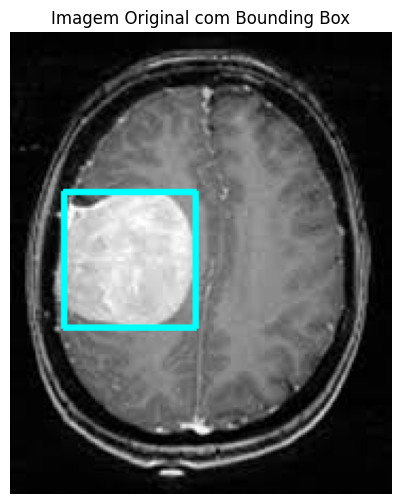


Conteúdo do arquivo de label (Y1.txt):
0 0.311111 0.490826 0.344444 0.293578



In [7]:
def generate_yolo_label_from_image(image_path, output_label_path):
    """
    Lê uma imagem, detecta o tumor, e salva a bounding box no formato YOLO.
    Retorna True se um label foi criado, False caso contrário.
    """
    # 1. Ler a imagem
    img = cv2.imread(image_path)
    if img is None:
        print(f"Erro: Não foi possível ler a imagem {image_path}")
        return False, None

    img_height, img_width, _ = img.shape
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Aplicar filtro para reduzir ruído
    blur = cv2.medianBlur(img_gray, 5)

    # 3. Thresholding para gerar máscara binária
    # NOTA: O thresholding adaptativo pode criar ruído. Um threshold simples pode ser melhor aqui.
    # Vamos tentar ambos. O threshold simples geralmente funciona bem para essa imagem específica.
    _, mask = cv2.threshold(blur, 190, 255, cv2.THRESH_BINARY)

    # 4. Refinar máscara com morfologia
    kernel = np.ones((5,5), np.uint8) # Usar um kernel um pouco maior pode ajudar a fechar buracos
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # 5. Encontrar contornos
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        print(f"AVISO: Nenhum contorno encontrado para a imagem {image_path}")
        return False, img # Retorna a imagem original para visualização

    # 6. Pegar o maior contorno (assumindo que seja o tumor)
    main_contour = max(contours, key=cv2.contourArea)

    # 7. Calcular a Bounding Box a partir do contorno
    x, y, w, h = cv2.boundingRect(main_contour)

    # --- ETAPA CRÍTICA: CONVERSÃO PARA O FORMATO YOLO ---
    # Coordenadas são normalizadas pela largura e altura da imagem
    x_center = (x + w / 2) / img_width
    y_center = (y + h / 2) / img_height
    norm_w = w / img_width
    norm_h = h / img_height

    # Classe 0 para 'tumor'
    class_id = 0

    # 8. Salvar no arquivo .txt
    with open(output_label_path, 'w') as f:
        f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}\n")

    print(f"Label salvo em: {output_label_path}")

    # --- ETAPA OPCIONAL: VISUALIZAÇÃO ---
    # Desenha o retângulo na imagem para verificação
    img_with_box = img.copy()
    cv2.rectangle(img_with_box, (x, y), (x + w, y + h), (255, 255, 0), 2) # ciano, espessura 2

    return True, img_with_box


# --- Exemplo de uso para uma imagem ---
image_file = '/content/brain_tumor_dataset/brain_tumor_dataset/yes/Y1.jpg'
label_file = '/content/Y1.txt' # Salvar o label na mesma pasta ou em uma pasta 'labels'

success, visualized_image = generate_yolo_label_from_image(image_file, label_file)

if success:
    # Mostrar o resultado
    plt.figure(figsize=(6,6))
    plt.title("Imagem Original com Bounding Box")
    plt.imshow(cv2.cvtColor(visualized_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    # Imprimir o conteúdo do arquivo de label gerado
    with open(label_file, 'r') as f:
        print("\nConteúdo do arquivo de label (Y1.txt):")
        print(f.read())

In [8]:
BASE_DATASET_PATH = '/content/brain_tumor_dataset/brain_tumor_dataset'
YES_FOLDER = os.path.join(BASE_DATASET_PATH, 'yes')
NO_FOLDER = os.path.join(BASE_DATASET_PATH, 'no')

OUTPUT_DIR = 'YOLO_Dataset'
TEMP_DIR = os.path.join(OUTPUT_DIR, 'temp')

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(TEMP_DIR, exist_ok=True)

# =============================================================================
# 3. PROCESSAMENTO E CRIAÇÃO DOS LABELS (Sem alterações)
# =============================================================================
yes_images = glob.glob(os.path.join(YES_FOLDER, '*.*'))
no_images = glob.glob(os.path.join(NO_FOLDER, '*.*'))
all_images = yes_images + no_images

print(f"Encontradas {len(yes_images)} imagens com tumor e {len(no_images)} imagens sem tumor.")
print("Processando e criando labels...")

for img_path in tqdm(all_images):
    base_filename = os.path.basename(img_path)
    name, _ = os.path.splitext(base_filename)
    new_img_filename = f"{name}.jpg"
    label_filename = f"{name}.txt"
    temp_img_path = os.path.join(TEMP_DIR, new_img_filename)
    temp_label_path = os.path.join(TEMP_DIR, label_filename)
    shutil.copy(img_path, temp_img_path)
    if img_path in yes_images:
        generate_yolo_label_from_image(img_path, temp_label_path)
    else:
        with open(temp_label_path, 'w') as f:
            pass
print("Criação de labels concluída.")

# =============================================================================
# 4. DIVISÃO EM TREINO E VALIDAÇÃO (LÓGICA CORRIGIDA)
# =============================================================================
print("\nDividindo arquivos em conjuntos de treino e validação...")

image_filenames = [f for f in os.listdir(TEMP_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
train_files, val_files = train_test_split(image_filenames, test_size=0.2, random_state=42)

# --- FUNÇÃO ATUALIZADA ---
def move_files_to_split(filenames, split_name):
    dest_img_dir = os.path.join(OUTPUT_DIR, split_name, 'images')
    dest_label_dir = os.path.join(OUTPUT_DIR, split_name, 'labels')
    os.makedirs(dest_img_dir, exist_ok=True)
    os.makedirs(dest_label_dir, exist_ok=True)

    for filename in tqdm(filenames, desc=f"Movendo arquivos para {split_name}"):
        # Caminho da imagem de origem
        source_img_path = os.path.join(TEMP_DIR, filename)

        # Move a imagem
        if os.path.exists(source_img_path):
            shutil.move(source_img_path, os.path.join(dest_img_dir, filename))

        # Define os caminhos do label correspondente
        name, _ = os.path.splitext(filename)
        label_filename = f"{name}.txt"
        source_label_path = os.path.join(TEMP_DIR, label_filename)

        # *** A VERIFICAÇÃO CRÍTICA ESTÁ AQUI ***
        # Move o label SOMENTE SE ele existir
        if os.path.exists(source_label_path):
            shutil.move(source_label_path, os.path.join(dest_label_dir, label_filename))
        # Se não existir, não faz nada e não quebra o programa.

# Executa a movimentação
move_files_to_split(train_files, 'train')
move_files_to_split(val_files, 'val')

# Remove a pasta temporária
shutil.rmtree(TEMP_DIR)

print("\nProcesso finalizado com sucesso!")
print(f"Seu dataset YOLO está pronto na pasta: '{OUTPUT_DIR}'")

Encontradas 155 imagens com tumor e 98 imagens sem tumor.
Processando e criando labels...


 16%|█▌        | 40/253 [00:00<00:00, 398.61it/s]

Label salvo em: YOLO_Dataset/temp/Y40.txt
Label salvo em: YOLO_Dataset/temp/Y160.txt
Label salvo em: YOLO_Dataset/temp/Y86.txt
Label salvo em: YOLO_Dataset/temp/Y36.txt
Label salvo em: YOLO_Dataset/temp/Y117.txt
Label salvo em: YOLO_Dataset/temp/Y17.txt
Label salvo em: YOLO_Dataset/temp/Y168.txt
Label salvo em: YOLO_Dataset/temp/Y158.txt
Label salvo em: YOLO_Dataset/temp/Y29.txt
Label salvo em: YOLO_Dataset/temp/Y188.txt
Label salvo em: YOLO_Dataset/temp/Y248.txt
Label salvo em: YOLO_Dataset/temp/Y257.txt
Label salvo em: YOLO_Dataset/temp/Y32.txt
Label salvo em: YOLO_Dataset/temp/Y85.txt
AVISO: Nenhum contorno encontrado para a imagem /content/brain_tumor_dataset/brain_tumor_dataset/yes/Y95.jpg
Label salvo em: YOLO_Dataset/temp/Y16.txt
Label salvo em: YOLO_Dataset/temp/Y90.txt
Label salvo em: YOLO_Dataset/temp/Y155.txt
Label salvo em: YOLO_Dataset/temp/Y4.txt
Label salvo em: YOLO_Dataset/temp/Y33.txt
Label salvo em: YOLO_Dataset/temp/Y187.txt
Label salvo em: YOLO_Dataset/temp/Y255.txt


 45%|████▌     | 115/253 [00:00<00:00, 317.94it/s]

Label salvo em: YOLO_Dataset/temp/Y39.txt
Label salvo em: YOLO_Dataset/temp/Y30.txt
Label salvo em: YOLO_Dataset/temp/Y9.txt
AVISO: Nenhum contorno encontrado para a imagem /content/brain_tumor_dataset/brain_tumor_dataset/yes/Y256.JPG
AVISO: Nenhum contorno encontrado para a imagem /content/brain_tumor_dataset/brain_tumor_dataset/yes/Y98.JPG
Label salvo em: YOLO_Dataset/temp/Y74.txt
Label salvo em: YOLO_Dataset/temp/Y146.txt
Label salvo em: YOLO_Dataset/temp/Y76.txt
Label salvo em: YOLO_Dataset/temp/Y22.txt
Label salvo em: YOLO_Dataset/temp/Y50.txt
Label salvo em: YOLO_Dataset/temp/Y11.txt
Label salvo em: YOLO_Dataset/temp/Y69.txt
Label salvo em: YOLO_Dataset/temp/Y56.txt
Label salvo em: YOLO_Dataset/temp/Y184.txt
Label salvo em: YOLO_Dataset/temp/Y3.txt
Label salvo em: YOLO_Dataset/temp/Y147.txt
Label salvo em: YOLO_Dataset/temp/Y79.txt
Label salvo em: YOLO_Dataset/temp/Y35.txt
Label salvo em: YOLO_Dataset/temp/Y77.txt
Label salvo em: YOLO_Dataset/temp/Y164.txt
Label salvo em: YOLO_Da

100%|██████████| 253/253 [00:00<00:00, 551.33it/s]


Label salvo em: YOLO_Dataset/temp/Y59.txt
Label salvo em: YOLO_Dataset/temp/Y6.txt
Label salvo em: YOLO_Dataset/temp/Y112.txt
Label salvo em: YOLO_Dataset/temp/Y259.txt
Label salvo em: YOLO_Dataset/temp/Y108.txt
Label salvo em: YOLO_Dataset/temp/Y163.txt
Label salvo em: YOLO_Dataset/temp/Y19.txt
Label salvo em: YOLO_Dataset/temp/Y161.txt
Label salvo em: YOLO_Dataset/temp/Y54.txt
Label salvo em: YOLO_Dataset/temp/Y253.txt
Label salvo em: YOLO_Dataset/temp/Y165.txt
Label salvo em: YOLO_Dataset/temp/Y120.txt
Criação de labels concluída.

Dividindo arquivos em conjuntos de treino e validação...


Movendo arquivos para val: 100%|██████████| 51/51 [00:00<00:00, 14021.34it/s]


Processo finalizado com sucesso!
Seu dataset YOLO está pronto na pasta: 'YOLO_Dataset'


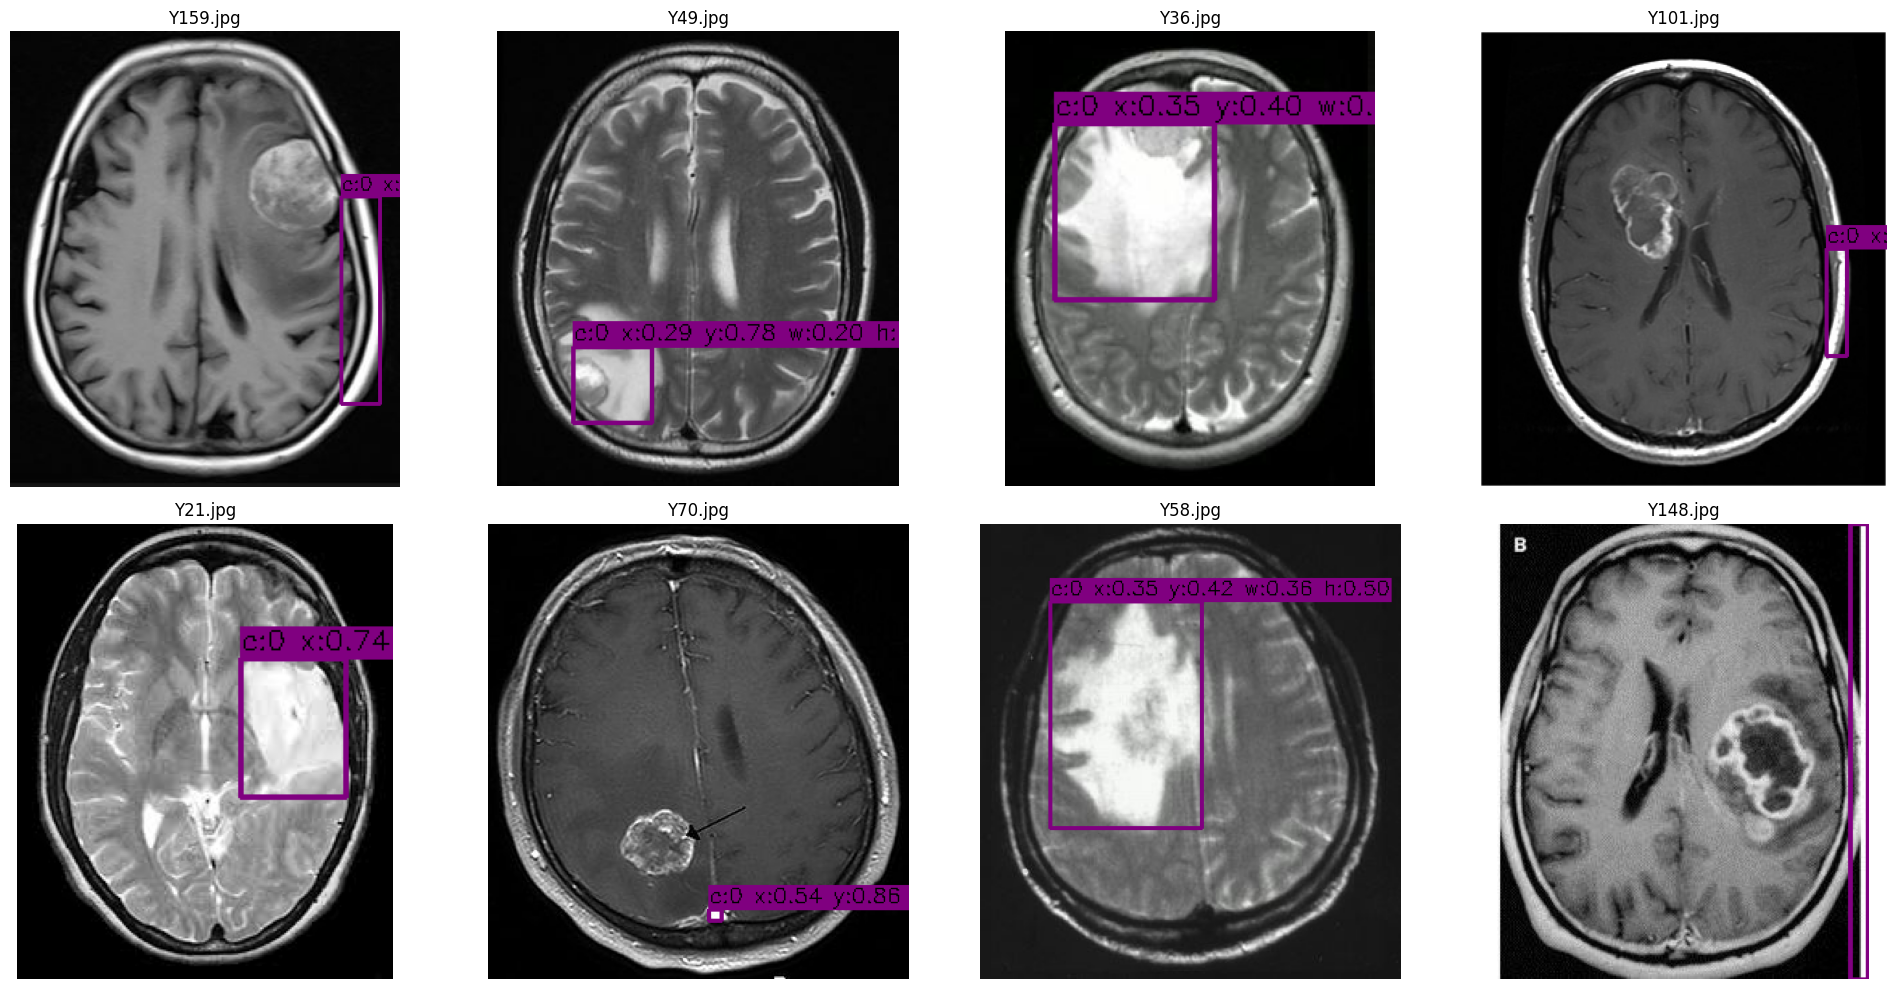

In [ ]:
def plot_yolo_samples(dataset_dir, num_samples=8):
    """
    Plota um número de amostras aleatórias do dataset YOLO com suas bounding boxes e labels.
    """
    train_img_dir = os.path.join(dataset_dir, 'train', 'images')
    train_label_dir = os.path.join(dataset_dir, 'train', 'labels')

    if not os.path.exists(train_img_dir):
        print(f"Erro: O diretório de imagens '{train_img_dir}' não foi encontrado.")
        return

    # Pega todas as imagens que possuem um label correspondente
    labeled_images = []
    for label_file in os.listdir(train_label_dir):
        # Checa se o arquivo de label não está vazio
        if os.path.getsize(os.path.join(train_label_dir, label_file)) > 0:
            name, _ = os.path.splitext(label_file)
            img_file = f"{name}.jpg"
            if os.path.exists(os.path.join(train_img_dir, img_file)):
                labeled_images.append(img_file)

    if len(labeled_images) < num_samples:
        print(f"Aviso: Encontradas apenas {len(labeled_images)} imagens com labels. Plotando todas.")
        num_samples = len(labeled_images)

    if num_samples == 0:
        print("Nenhuma imagem com label encontrada para plotar.")
        return

    # Seleciona amostras aleatórias
    sample_images = random.sample(labeled_images, num_samples)

    # Configura o plot (2 linhas, 4 colunas)
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten() # Transforma o array 2x4 em um array linear de 8 posições

    for i, img_filename in enumerate(sample_images):
        # Caminho da imagem e do label
        img_path = os.path.join(train_img_dir, img_filename)
        label_path = os.path.join(train_label_dir, f"{os.path.splitext(img_filename)[0]}.txt")

        # Lê a imagem
        img = cv2.imread(img_path)
        img_height, img_width, _ = img.shape

        # Lê o label
        with open(label_path, 'r') as f:
            line = f.readline().strip().split()
            class_id, x_center, y_center, norm_w, norm_h = [float(val) for val in line]

        # --- De-normaliza as coordenadas ---
        # Converte as coordenadas do formato YOLO para o formato de pixels do OpenCV
        w = norm_w * img_width
        h = norm_h * img_height
        x1 = int((x_center * img_width) - (w / 2))
        y1 = int((y_center * img_height) - (h / 2))
        x2 = int(x1 + w)
        y2 = int(y1 + h)

        # Desenha a bounding box na imagem (em verde)
        cv2.rectangle(img, (x1, y1), (x2, y2), (128, 0, 128), 2)

        # Prepara o texto do label para ser exibido
        label_text = f"c:{int(class_id)} x:{x_center:.2f} y:{y_center:.2f} w:{norm_w:.2f} h:{norm_h:.2f}"

        # Coloca um fundo para o texto para melhor legibilidade
        (text_width, text_height), baseline = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(img, (x1, y1 - text_height - 5), (x1 + text_width, y1), (128, 0, 128), -1)

        # Escreve o texto do label na imagem (em preto)
        cv2.putText(img, label_text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)

        # Converte a imagem de BGR (OpenCV) para RGB (Matplotlib) e a plota
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(img_filename)
        axes[i].axis('off')

    # Esconde eixos que não foram usados, caso num_samples < 8
    for i in range(num_samples, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# --- Executa a função ---
# Certifique-se de que a pasta 'YOLO_Dataset' está no diretório correto
plot_yolo_samples('YOLO_Dataset', num_samples=8)

com essas labels vai auxiliar o modelo na onde ele precisa focar na hora de aprender.

In [ ]:
%%writefile dataset.yaml
path: brain-tumor # dataset root dir
train: images/train # train images (relative to 'path') 893 images
val: images/val # val images (relative to 'path') 223 images

# Classes
names:
  0: negative
  1: positive

# Download script/URL (optional)
download: https://github.com/ultralytics/assets/releases/download/v0.0.0/brain-tumor.zip

Writing dataset.yaml


In [ ]:
model = YOLO("/content/yolo12n.pt")
model.train(
    data="dataset.yaml",  # arquivo YAML
    epochs=10,            # ajuste conforme necessidade
    imgsz=640,            # tamanho das imagens
    batch=32,             # ajuste conforme memória da GPU
    name="meu_treinamento"
)

Ultralytics 8.3.211 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=meu_treinamento, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pos

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e2efdf6f680>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
%%writefile my_dataset.yaml
# YAML do seu dataset personalizado
path: /content/YOLO_Dataset
train: train/images
val: val/images

# Classes (apenas uma classe, 'tumor')
names:
  0: tumor

Writing my_dataset.yaml


In [ ]:
model_finetune = YOLO('/content/runs/detect/meu_treinamento/weights/best.pt')

# Continue o treinamento (fine-tuning) com o seu dataset
results_step2 = model_finetune.train(
    data='my_dataset.yaml',
    epochs=10,  # Para fine-tuning, geralmente são necessárias menos épocas
    imgsz=640,
    name='yolov12_finetuned_on_custom_data' # Novo nome para este experimento
)

Ultralytics 8.3.211 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=my_dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/detect/meu_treinamento/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov12_finetuned_on_custom_data, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

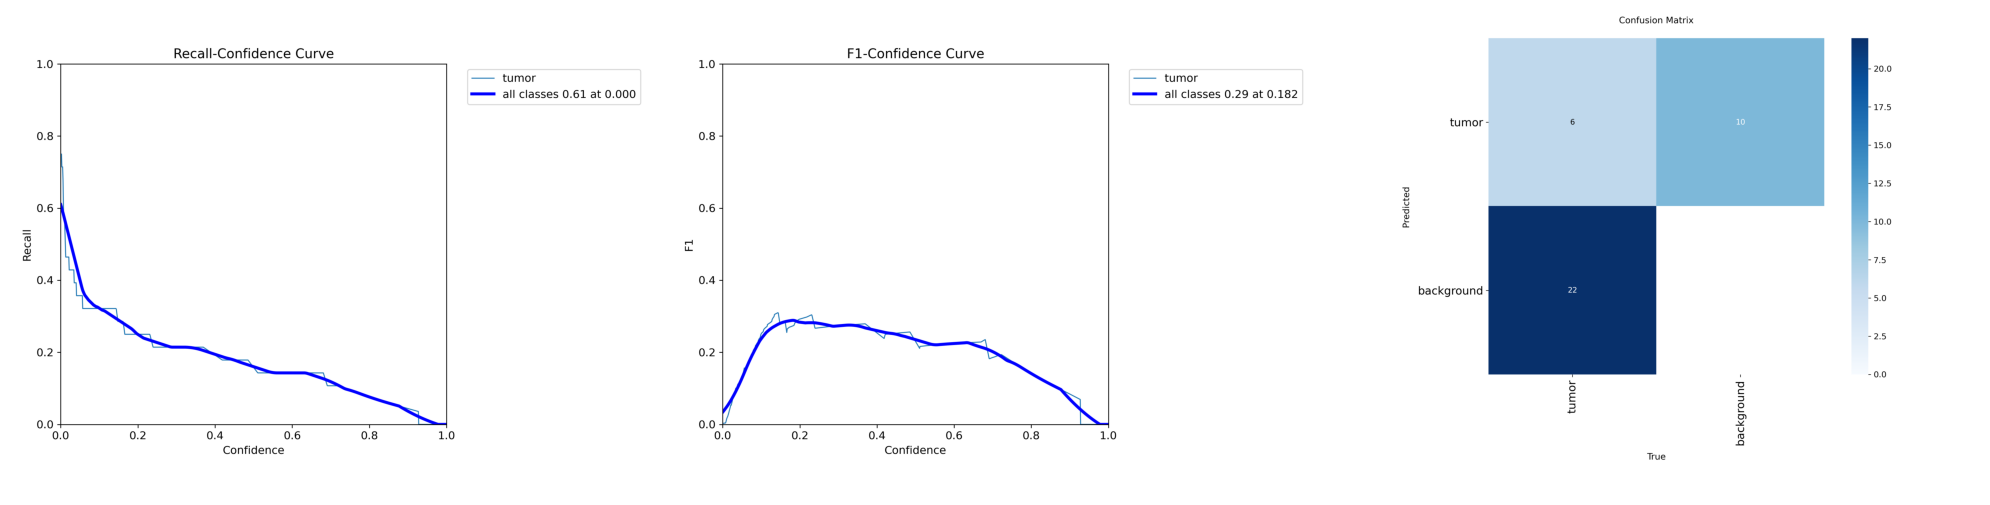

In [ ]:
import matplotlib.image as mpimg
images = [
    '/content/runs/detect/yolov12_finetuned_on_custom_data/BoxR_curve.png',
    '/content/runs/detect/yolov12_finetuned_on_custom_data/BoxF1_curve.png',
    '/content/runs/detect/yolov12_finetuned_on_custom_data/confusion_matrix.png'
]

# Cria figura com 3 subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(20,6))

for ax, img_path in zip(axes, images):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis('off')  # remove eixos

plt.tight_layout()
plt.show()

exemplo de seguimentação que foi feito pelo yolo


image 1/1 /content/YOLO_Dataset/val/images/Y15.jpg: 640x544 (no detections), 62.0ms
Speed: 3.5ms preprocess, 62.0ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 544)

image 1/1 /content/YOLO_Dataset/val/images/Y76.jpg: 640x512 (no detections), 60.0ms
Speed: 2.5ms preprocess, 60.0ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 512)

image 1/1 /content/YOLO_Dataset/val/images/Y41.jpg: 640x576 (no detections), 66.1ms
Speed: 3.5ms preprocess, 66.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 576)

image 1/1 /content/YOLO_Dataset/val/images/Y259.jpg: 640x576 1 tumor, 14.7ms
Speed: 2.9ms preprocess, 14.7ms inference, 8.3ms postprocess per image at shape (1, 3, 640, 576)

image 1/1 /content/YOLO_Dataset/val/images/Y109.jpg: 640x608 (no detections), 65.6ms
Speed: 2.6ms preprocess, 65.6ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 608)

image 1/1 /content/YOLO_Dataset/val/images/Y90.jpg: 640x640 1 tumor, 18.7ms
Speed: 2.9ms prepro

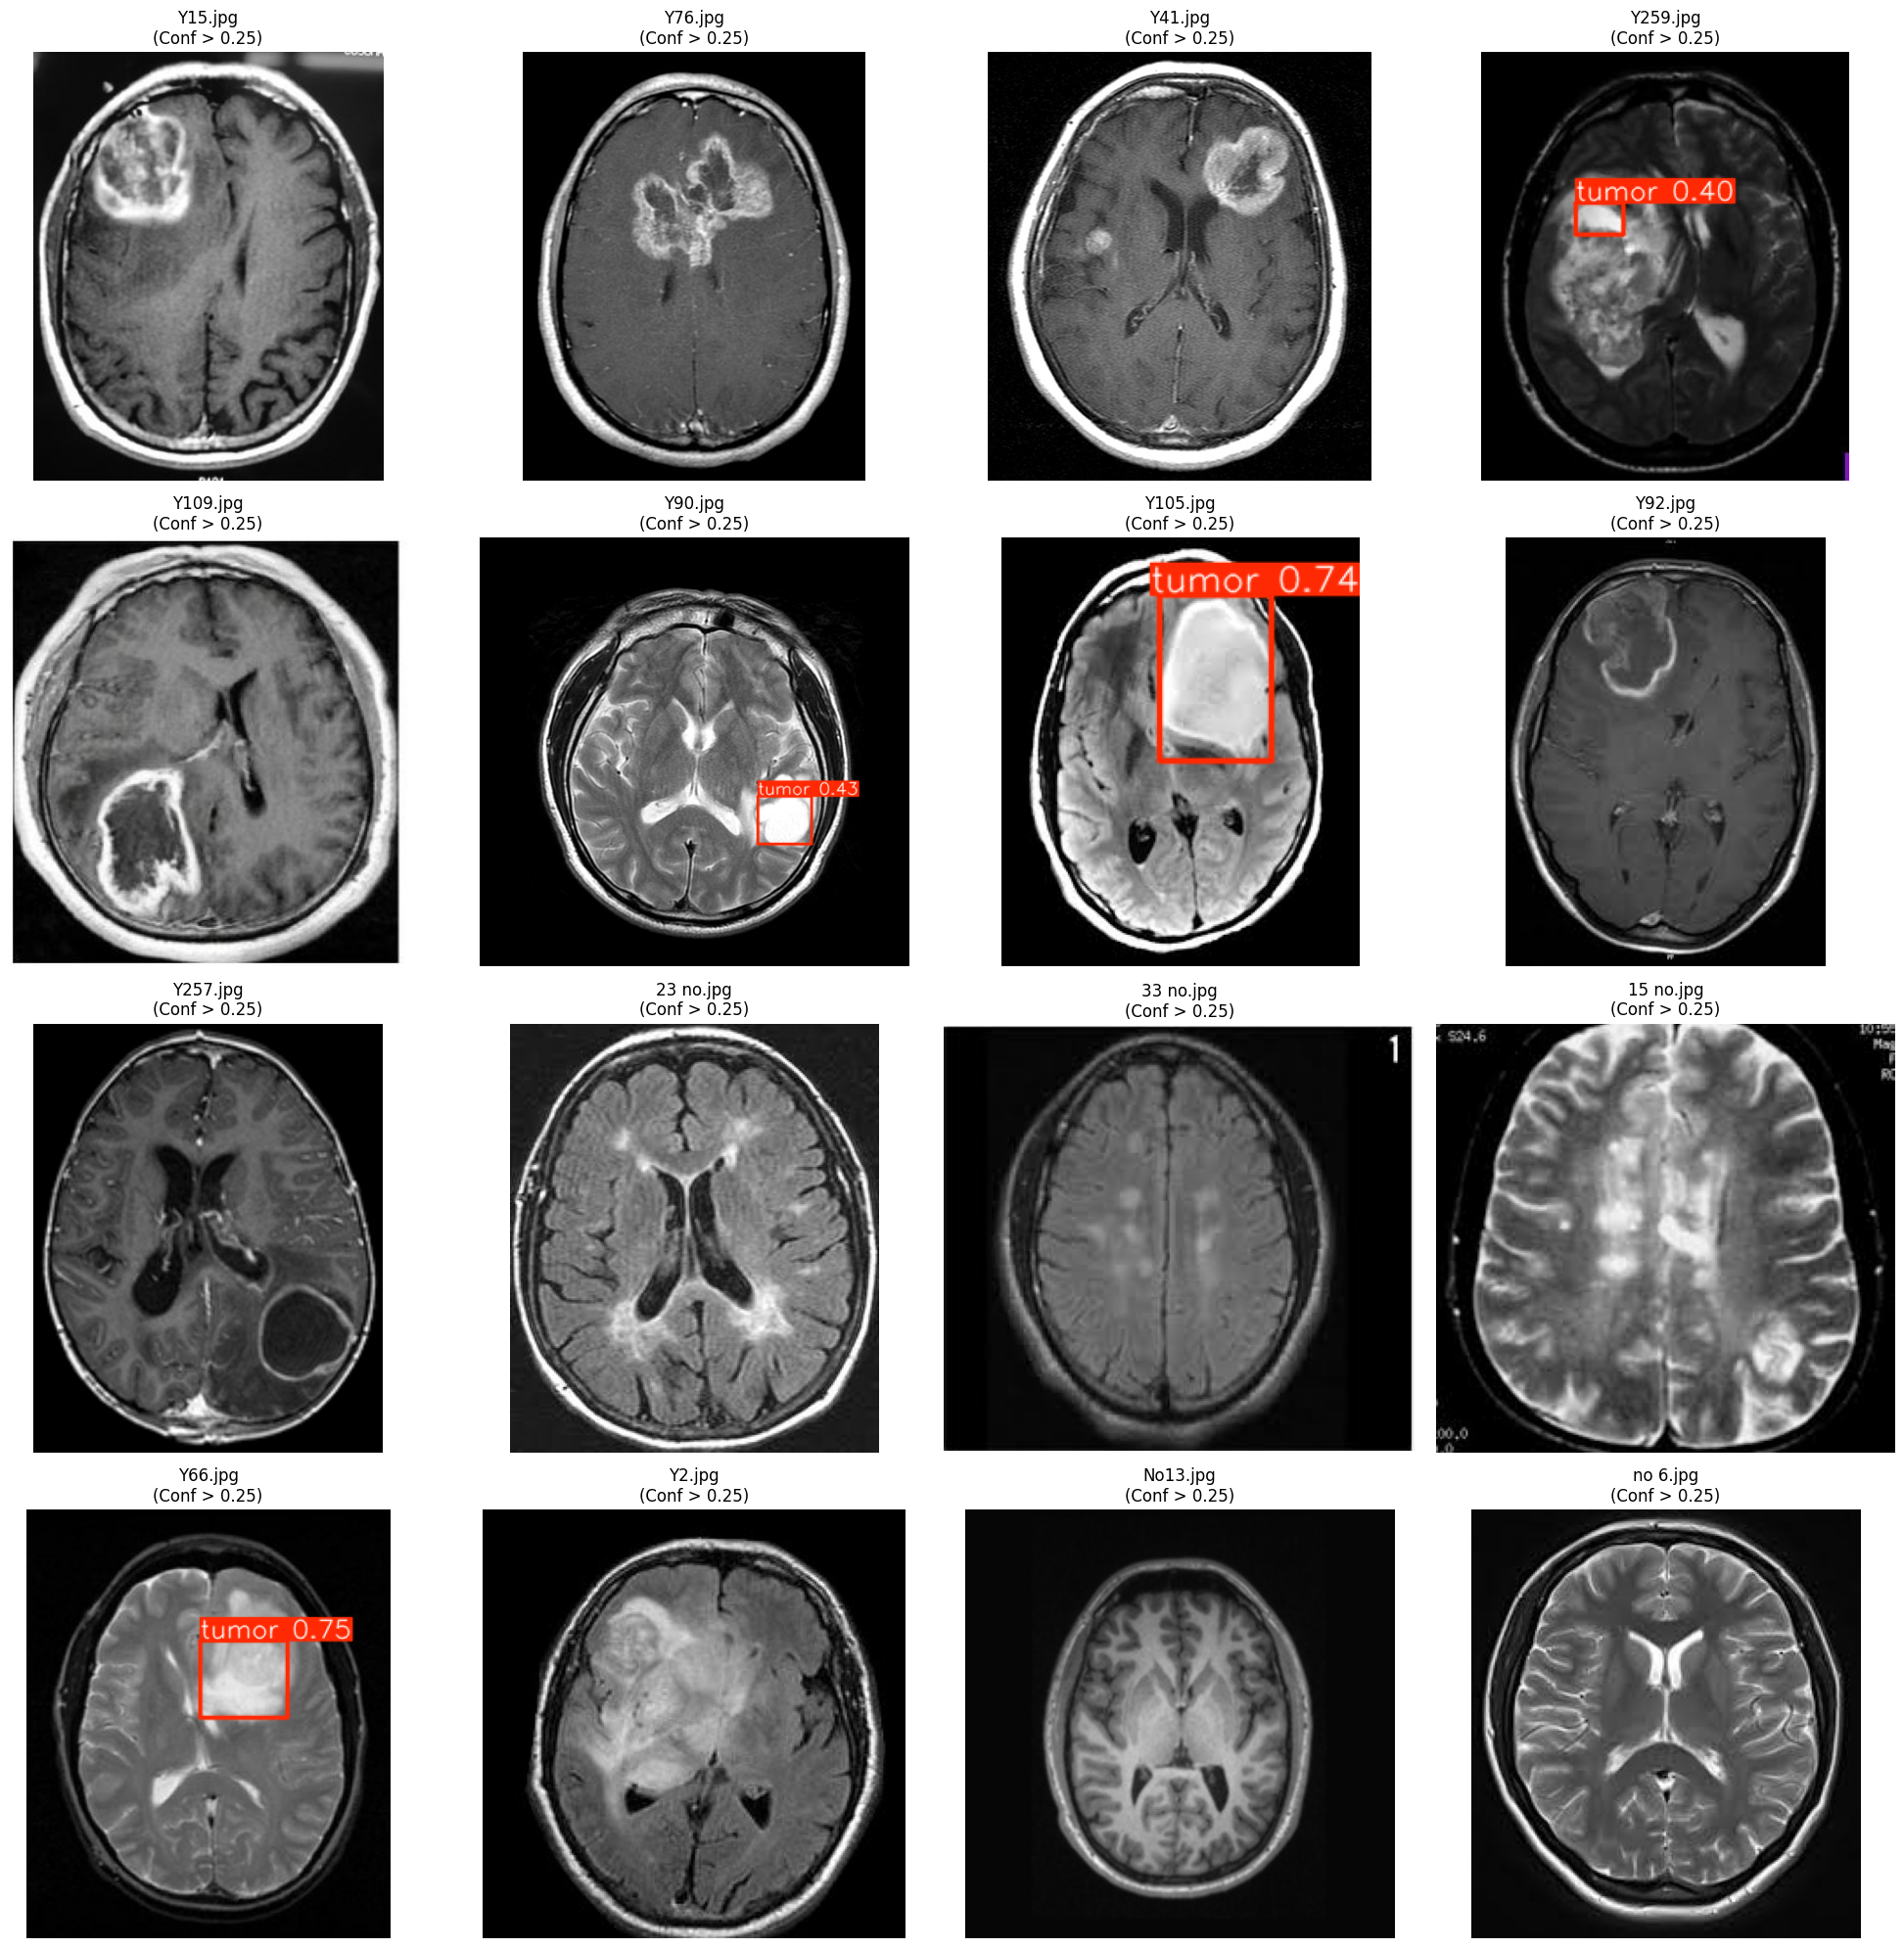

In [ ]:

model_path = '/content/runs/detect/yolov12_finetuned_on_custom_data/weights/best.pt'

# Verifica se o modelo existe antes de carregar
if not os.path.exists(model_path):
    print(f"ERRO: Modelo não encontrado em '{model_path}'")
    print("Por favor, verifique se o nome da pasta ('yolov8_finetuned_on_custom_data') está correto.")
else:
    model = YOLO(model_path)

    # --- 2. Selecionar 16 imagens aleatórias do conjunto de validação ---
    val_images_dir = '/content/YOLO_Dataset/val/images'
    all_val_images = os.listdir(val_images_dir)

    # Garante que não tentamos pegar mais imagens do que as disponíveis
    num_to_plot = min(16, len(all_val_images))

    if num_to_plot > 0:
        sampled_images = random.sample(all_val_images, num_to_plot)

        # --- 3. Configurar o plot ---
        fig, axes = plt.subplots(4, 4, figsize=(20, 20))
        axes = axes.flatten() # Transforma a grade 4x4 em um array linear

        # --- 4. Executar predição e plotar ---
        for i, img_filename in enumerate(sampled_images):
            img_path = os.path.join(val_images_dir, img_filename)

            # Executa a predição. O confidence threshold (conf) pode ser ajustado.
            results = model.predict(source=img_path, conf=0.25)

            # O método plot() da ultralytics já desenha as caixas na imagem
            # Ele retorna um array numpy da imagem em formato RGB
            plotted_image = results[0].plot()

            # Mostra a imagem no subplot correspondente
            axes[i].imshow(plotted_image)
            axes[i].set_title(f"{img_filename}\n(Conf > 0.25)")
            axes[i].axis('off')

        # Esconde os eixos que não foram usados, caso haja menos de 16 imagens
        for j in range(num_to_plot, len(axes)):
            axes[j].axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print(f"Nenhuma imagem encontrada no diretório de validação: {val_images_dir}")


arquivo dataset

# CNN VGG16

bem tive problemas com o vazamento de dados, logo estou usando tecnicas para evitar isso

In [ ]:
from keras.applications.vgg16 import VGG16
from keras.models import Model
from keras.layers import Dense, Flatten
from keras.preprocessing.image import ImageDataGenerator

In [9]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
for layer in base_model.layers:
    layer.trainable = False

In [37]:
import os
import shutil
from tqdm import tqdm

# Diretório de origem (onde estão seus dados YOLO)
YOLO_DATA_DIR = 'YOLO_Dataset'
# Diretório de destino (para o modelo de classificação VGG16)
VGG16_DATA_DIR = 'VGG16_Dataset'

# Limpa o diretório de destino se ele já existir, para começar do zero
if os.path.exists(VGG16_DATA_DIR):
    shutil.rmtree(VGG16_DATA_DIR)

print(f"Criando a estrutura de pastas para VGG16 em '{VGG16_DATA_DIR}'...")

# Loop para processar os conjuntos 'train' e 'val'
for split in ['train', 'val']:
    source_img_dir = os.path.join(YOLO_DATA_DIR, split, 'images')
    source_label_dir = os.path.join(YOLO_DATA_DIR, split, 'labels')

    # Cria as pastas de destino (ex: VGG16_Dataset/train/tumor)
    dest_tumor_dir = os.path.join(VGG16_DATA_DIR, split, 'tumor')
    dest_no_tumor_dir = os.path.join(VGG16_DATA_DIR, split, 'no_tumor')
    os.makedirs(dest_tumor_dir, exist_ok=True)
    os.makedirs(dest_no_tumor_dir, exist_ok=True)

    print(f"\nProcessando o conjunto '{split}'...")
    for img_filename in tqdm(os.listdir(source_img_dir), desc=f"Copiando imagens de {split}"):
        name, _ = os.path.splitext(img_filename)
        label_path = os.path.join(source_label_dir, f"{name}.txt")

        # Se o arquivo de label existe e não está vazio, é um tumor
        if os.path.exists(label_path) and os.path.getsize(label_path) > 0:
            shutil.copy(os.path.join(source_img_dir, img_filename), dest_tumor_dir)
        # Se não, é sem tumor
        else:
            shutil.copy(os.path.join(source_img_dir, img_filename), dest_no_tumor_dir)

print("\nDataset para VGG16 criado com sucesso!")

Criando a estrutura de pastas para VGG16 em 'VGG16_Dataset'...

Processando o conjunto 'train'...


Copiando imagens de train: 100%|██████████| 201/201 [00:00<00:00, 9222.18it/s]



Processando o conjunto 'val'...


Copiando imagens de val: 100%|██████████| 51/51 [00:00<00:00, 4881.66it/s]


Dataset para VGG16 criado com sucesso!


In [38]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


TRAIN_DIR = '/content/VGG16_Dataset/train'
VAL_DIR = '/content/VGG16_Dataset/val'

IMG_SIZE = (224, 224)
RANDOM_SEED = 42

train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    vertical_flip=True,
    preprocessing_function=preprocess_input
)

# Gerador para VALIDAÇÃO (seu código aqui está perfeito)
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# --- AGORA OS GERADORES VÃO FUNCIONAR ---
# Gerador de Treino
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    color_mode='rgb',
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='binary',
    seed=RANDOM_SEED
)

# Gerador de Validação
validation_generator = test_datagen.flow_from_directory(
    VAL_DIR,
    color_mode='rgb',
    target_size=IMG_SIZE,
    batch_size=16,
    class_mode='binary',
    seed=RANDOM_SEED
)

Found 201 images belonging to 2 classes.
Found 51 images belonging to 2 classes.


treinando o modelo vgg16

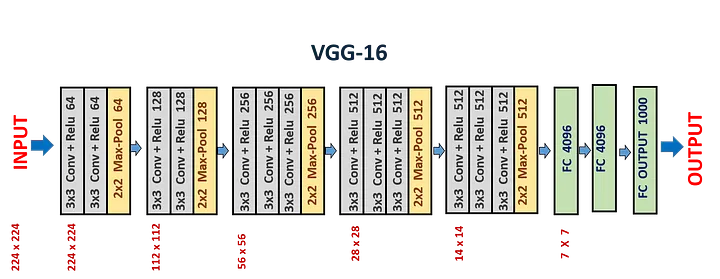

criando o modelo vgg16

tivemos uma perfomace ruim com o modelo com isso resolvi usar L2 lasso para o peso de 000.1 para diminuir o problema de overfit

In [39]:
model = tf.keras.models.Sequential() # implementação do modelo vgg16

                                     #  usando a função de ativação relu
                                     # usando L2 para o peso da rede neural
# camada 1
model.add(Conv2D(64, kernel_size=(3,3), padding="same", activation='relu',
                 input_shape=(224,224,3), kernel_regularizer=l2(0.001))) # para o canal rgb
model.add(Conv2D(64, kernel_size=(3,3), padding="same", activation='relu',
                 kernel_regularizer=l2(0.001)))
model.add(MaxPooling2D((2,2), strides=(2,2))) # strides conntrola o movimento do pooling para toda a matriz

# camada 2
model.add(Conv2D(64, kernel_size=(3,3), padding="same", activation='relu',
                 kernel_regularizer=l2(0.001))) # para o canal rgb
model.add(Conv2D(64, kernel_size=(3,3), padding="same", activation='relu',
                 kernel_regularizer=l2(0.001)))
model.add(MaxPooling2D((2,2), strides=(2,2)))

#camada 3
model.add(Conv2D(128, kernel_size=(3,3), padding="same", activation='relu',
                 kernel_regularizer=l2(0.001)))
model.add(Conv2D(128, kernel_size=(3,3), padding="same", activation='relu',
                 kernel_regularizer=l2(0.001))) # para o canal rgb
model.add(Conv2D(128, kernel_size=(3,3), padding="same", activation='relu',
                 kernel_regularizer=l2(0.001)))
model.add(MaxPooling2D((2,2), strides=(2,2)))

# camada 4
model.add(Conv2D(256, kernel_size=(3,3), padding="same", activation='relu',
                 kernel_regularizer=l2(0.001)))
model.add(Conv2D(256, kernel_size=(3,3), padding="same", activation='relu',
                 kernel_regularizer=l2(0.001))) # para o canal rgb
model.add(Conv2D(256, kernel_size=(3,3), padding="same", activation='relu',
                 kernel_regularizer=l2(0.001)))
model.add(MaxPooling2D((2,2), strides=(2,2)))

#camada 5
model.add(Conv2D(512, kernel_size=(3,3), padding="same", activation='relu',
                 kernel_regularizer=l2(0.001)))
model.add(Conv2D(512, kernel_size=(3,3), padding="same", activation='relu',
                 kernel_regularizer=l2(0.001))) # para o canal rgb
model.add(Conv2D(512, kernel_size=(3,3), padding="same", activation='relu',
                 kernel_regularizer=l2(0.001)))
model.add(MaxPooling2D((2,2), strides=(2,2)))



## flatten

In [40]:
model.add(Flatten())
model.add(Dense(4096, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dense(4096, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dense(1, activation='sigmoid', kernel_regularizer=l2(0.001))) # 3x camadas densas, com um ativador mulltilabel softmax

In [41]:
model.build()
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_39 (Conv2D)              │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,406,657 (486.02 MB)

 Trainable params: 127,406,657 (486.02 MB)

 Non-trainable params: 0 (0.00 B)

compilação do modelo

In [42]:
model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])


In [43]:
checkpoint = ModelCheckpoint('best_tumor_model.h5', monitor='val_accuracy',
                             save_best_only=True, verbose=1)
early = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

In [44]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[checkpoint, early]
)


Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4710 - loss: 15.1828   
Epoch 1: val_accuracy improved from -inf to 0.54902, saving model to best_tumor_model.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.4756 - loss: 15.1338 - val_accuracy: 0.5490 - val_loss: 13.6684
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.5423 - loss: 13.5248
Epoch 2: val_accuracy did not improve from 0.54902
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 578ms/step - accuracy: 0.5460 - loss: 13.5028 - val_accuracy: 0.5490 - val_loss: 12.9560
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.5902 - loss: 12.7990
Epoch 3: val_accuracy did not improve from 0.54902
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 578ms/step - accuracy: 0.5948 - loss: 12.7815 - val_accuracy: 0.5490 - val_loss: 12.3154
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.6918 - loss: 12.0537
Epoch 4: val_accuracy improved from 0.54902 to 0.76471, saving model to best_tumor_model.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.6924 - loss: 12.0353 - val_accuracy: 0.7647 - val_loss: 11.5232
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.7313 - loss: 11.4130
Epoch 5: val_accuracy did not improve from 0.76471
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 572ms/step - accuracy: 0.7294 - loss: 11.3950 - val_accuracy: 0.6078 - val_loss: 11.1857
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 741ms/step - accuracy: 0.7005 - loss: 10.8274
Epoch 6: val_accuracy did not improve from 0.76471
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 867ms/step - accuracy: 0.7025 - loss: 10.8090 - val_accuracy: 0.7255 - val_loss: 10.4119
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.7423 - loss: 10.2280
Epoch 7: val_accuracy did not improve from 0.76471
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 647ms/step - accuracy: 0.7372 - loss: 10.2218 - val_accuracy: 0.6863 - val_loss: 10.0324
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.6913 - loss: 9.8430
Epoch 8: val_accuracy did not improve from

7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 4s/step - accuracy: 0.6854 - loss: 9.3289 - val_accuracy: 0.7843 - val_loss: 9.0521
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.7686 - loss: 8.8518
Epoch 10: val_accuracy did not improve from 0.78431
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 624ms/step - accuracy: 0.7677 - loss: 8.8472 - val_accuracy: 0.7647 - val_loss: 8.8136
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.7636 - loss: 8.5005
Epoch 11: val_accuracy did not improve from 0.78431
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 567ms/step - accuracy: 0.7608 - loss: 8.4973 - val_accuracy: 0.7255 - val_loss: 8.3342
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.8124 - loss: 8.1667
Epoch 12: val_accuracy did not improve from 0.78431
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 609ms/step - accuracy: 0.8066 - loss: 8.1605 - val_accuracy: 0.7647 - val_loss: 7.9695
Epoch 13/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.8417 - loss: 7.7301
Epoch 13: val_accuracy did not improve from 0.

7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 5s/step - accuracy: 0.7878 - loss: 6.9596 - val_accuracy: 0.8039 - val_loss: 6.8837
Epoch 17/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accuracy: 0.7937 - loss: 6.6960
Epoch 17: val_accuracy did not improve from 0.80392
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 682ms/step - accuracy: 0.7890 - loss: 6.6956 - val_accuracy: 0.7059 - val_loss: 6.6336
Epoch 18/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.7378 - loss: 6.5270
Epoch 18: val_accuracy did not improve from 0.80392
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 636ms/step - accuracy: 0.7376 - loss: 6.5229 - val_accuracy: 0.7451 - val_loss: 6.4486
Epoch 19/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.7798 - loss: 6.3137
Epoch 19: val_accuracy did not improve from 0.80392
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 574ms/step - accuracy: 0.7799 - loss: 6.3084 - val_accuracy: 0.8039 - val_loss: 6.2918
Epoch 20/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.8136 - loss: 6.0695
Epoch 20: val_accuracy did not improve from 0.

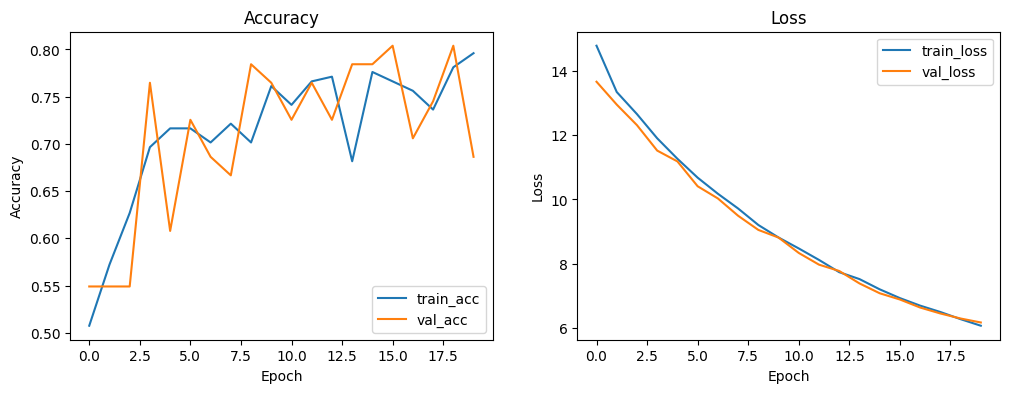

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [46]:
from tensorflow.keras.models import load_model

model = load_model("best_tumor_model.h5")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 655ms/step
 Tumor Detected


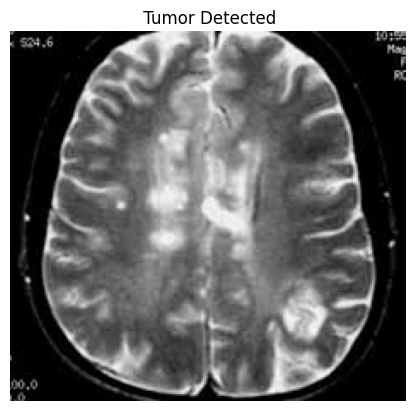

In [48]:
from tensorflow.keras.preprocessing import image
import numpy as np
model = load_model("/content/best_tumor_model.h5")

img_path = "/content/YOLO_Dataset/val/images/15 no.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

prediction = model.predict(img_array)

plt.imshow(image.load_img(img_path))
plt.axis("off")
if prediction[0][0] > 0.4:
    plt.title(" Tumor Detected")
    print(" Tumor Detected")
else:
    plt.title(" No Tumor Detected")
    print(" No Tumor Detected")
plt.show()